# Swift Dock Tutorial 🚀
## Let's Design a Molecule for a Disease Target


<div align="center">

<td align="center"><img src="notebook_assets/corona-virus.jpg" width="430|"></td>

<br>

<b>Swift Dock: from molecules to predicted docking scores</b>

</div>


Welcome to a story-driven notebook.

Today, we will imagine that we are building a small drug-discovery assistant.

Our mission:

> **Can we screen new molecules and predict which one may bind best to a disease-related protein?**

We will use the Swift Dock workflow:

    Molecule → Features → Trained model → Predicted docking score → Rank candidates

We will not train a model here.  
Instead, we will load a model that was already trained earlier.


In [38]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/Users/abdulsalamyazid/PycharmProjects/swifty")
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source folder:", SRC_DIR)
print("Project exists:", PROJECT_ROOT.exists())
print("Source exists:", SRC_DIR.exists())


Project root: /Users/abdulsalamyazid/PycharmProjects/swifty
Source folder: /Users/abdulsalamyazid/PycharmProjects/swifty/src
Project exists: True
Source exists: True


# 1. Choose a Disease Target 🦠


<div align="center">
<table>
<tr>
<td align="center"><img src="notebook_assets/corona-virus.jpg" width="300"></td>
<td align="center"><img src="notebook_assets/sars-cov-2-spikes.jpg" width="300"></td>
</tr>
<tr>
<td align="center"><b>Disease context</b></td>
<td align="center"><b>Spike protein target</b></td>
</tr>
</table>
</div>


Let us frame the story around coronavirus.

A drug-discovery workflow often starts by choosing a disease-related protein as the **target**.

In this demo, we use the idea of targeting the **SARS-CoV-2 spike protein**.

The goal:

> Find candidate molecules that may bind strongly to the target protein.


## Protein Target View


<div align="center">

<img src="notebook_assets/protein.jpg" width="520">

</div>


A protein is a large biological molecule with a 3D structure.  
A candidate drug molecule may bind to a pocket or surface region on the protein.

This binding interaction is what molecular docking tries to estimate.


# 2. Explore the Docking Dataset 🔍

Before predicting new molecules, let us inspect the dataset used by the project.

The dataset contains:

- `smile`: molecule represented as text
- `docking_score`: docking result from molecular docking software

Usually:

    More negative docking score → stronger predicted binding


In [39]:
import pandas as pd

DATA_PATH = PROJECT_ROOT / "datasets" / "sample_input.csv"
data = pd.read_csv(DATA_PATH).dropna().reset_index(drop=True)

print("Dataset path:", DATA_PATH)
print("Dataset shape:", data.shape)

data.head()


Dataset path: /Users/abdulsalamyazid/PycharmProjects/swifty/datasets/sample_input.csv
Dataset shape: (1000, 2)


,docking_score,smile
0,-6.0,C[C@H](C(=O)O)c1ccc2oc(c3ccc(Cl)cc3)nc2c1
1,-5.1,CC(C)(C)C(=O)[C@H](Oc1ccc(Cl)cc1)n1ccnc1
2,-5.1,CCN(CC)CC(=O)N1c2ccccc2Sc2ccccc12
3,-4.6,CN(C)CCO[C@@](C)(c1ccccc1)c1ccccn1
4,-4.4,CCN(CC)C(=O)c1ccc(O)c(OC)c1


## Quick Look at the Docking Scores

This gives us a quick feeling for the range of scores in the dataset.


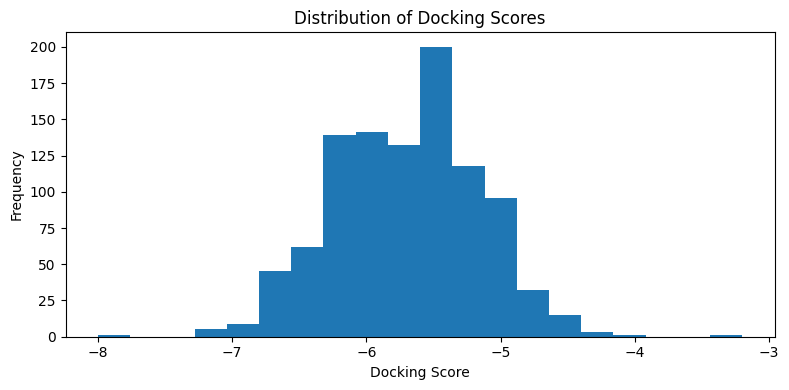

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(data["docking_score"], bins=20)
plt.xlabel("Docking Score")
plt.ylabel("Frequency")
plt.title("Distribution of Docking Scores")
plt.tight_layout()
plt.show()


# 3. What Does a Molecule Look Like? 🧪

The dataset stores molecules as SMILES strings.

Let us take one molecule from the dataset and draw it.

This is the bridge between chemistry and machine learning:  
the molecule starts as a chemical structure, but the model will eventually see it as numbers.


In [41]:
sample_row = data.iloc[0]
sample_smile = sample_row["smile"]
sample_score = sample_row["docking_score"]

print("Sample SMILES:", sample_smile)
print("Docking score:", sample_score)


Sample SMILES: C[C@H](C(=O)O)c1ccc2oc(c3ccc(Cl)cc3)nc2c1
Docking score: -6.0


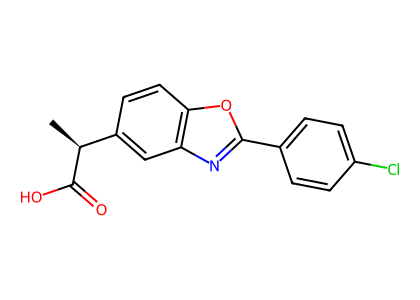

In [42]:
from rdkit import Chem
from rdkit.Chem import Draw

mol = Chem.MolFromSmiles(sample_smile)

if mol is not None:
    display(Draw.MolToImage(mol, size=(420, 300)))
else:
    print("RDKit could not parse this SMILES.")


# 4. Featurization: Turning Chemistry into Numbers 🔢


<div align="center">
<table>
<tr>
<td align="center"><img src="notebook_assets/drug.jpg" width="260"></td>
<td align="center"><img src="notebook_assets/molecule.jpg" width="260"></td>
<td align="center"><img src="notebook_assets/machine-learning.png" width="260"></td>
</tr>
<tr>
<td align="center"><b>Candidate molecules</b></td>
<td align="center"><b>Molecular features</b></td>
<td align="center"><b>ML prediction</b></td>
</tr>
</table>
</div>


Machine learning models cannot directly understand a molecule drawing.

So we convert each molecule into numerical features.

For this notebook, we use the `mac` descriptor, based on MACCS molecular fingerprints.

Think of it as converting a molecule into a chemical barcode.


In [23]:
from features.smiles_featurizers import mac_keys_fingerprints

sample_features = mac_keys_fingerprints(sample_smile)

print("Feature type:", type(sample_features))
print("Feature shape:", sample_features.shape)
print("First 30 feature values:")
print(sample_features[:30])


Feature type: <class 'numpy.ndarray'>
Feature shape: (167,)
First 30 feature values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


## Visualizing the Fingerprint

A molecular fingerprint is like a barcode for a molecule.

Each position represents whether a certain chemical pattern is present or absent.


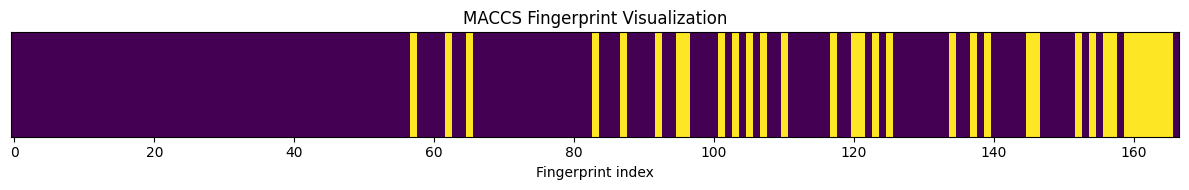

In [43]:
plt.figure(figsize=(12, 2))
plt.imshow(sample_features.reshape(1, -1), aspect="auto")
plt.yticks([])
plt.xlabel("Fingerprint index")
plt.title("MACCS Fingerprint Visualization")
plt.tight_layout()
plt.show()


# 5. Load the Trained LSTM Model 🧠

Now we load a model that was already trained earlier.

We will use this model path:

    /Users/abdulsalamyazid/PycharmProjects/swifty/results_seq/serialized_models/lstm_sample_input_mac_50_model.pt

The model was trained to predict docking scores from molecular features.


In [44]:
import torch
from core.model import AttentionNetwork

MODEL_PATH = PROJECT_ROOT / "results_seq" / "serialized_models" / "lstm_sample_input_mac_50_model.pt"

print("Model path:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

checkpoint = torch.load(
    MODEL_PATH,
    map_location=torch.device("cpu"),
    weights_only=False
)

num_of_features = checkpoint["num_of_features"]
sequence_length = checkpoint.get("sequence_length", 8)

model = AttentionNetwork(num_of_features, sequence_length)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Model loaded successfully.")
print("Number of features:", num_of_features)
print("Sequence length:", sequence_length)


Model path: /Users/abdulsalamyazid/PycharmProjects/swifty/results_seq/serialized_models/lstm_sample_input_mac_50_model.pt
Model exists: True
Model loaded successfully.
Number of features: 167
Sequence length: 369


# 6. Predict Docking Scores for New Molecules 🎯

Now comes the fun part.

Let us create a small list of new candidate molecules.

The model will predict docking scores for them, then we will rank them.

Remember:

    More negative predicted docking score → stronger predicted binding


In [45]:
candidate_molecules = [
    {"name": "Aspirin", "smile": "CC(=O)Oc1ccccc1C(=O)O"},
    {"name": "Paracetamol", "smile": "CC(=O)Nc1ccc(O)cc1"},
    {"name": "Caffeine", "smile": "Cn1cnc2c1c(=O)n(C)c(=O)n2C"},
    {"name": "Ibuprofen", "smile": "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O"},
    {"name": "Simple alcohol", "smile": "CCO"},
    {"name": "Benzene", "smile": "c1ccccc1"}
]

candidate_molecules


[{'name': 'Aspirin', 'smile': 'CC(=O)Oc1ccccc1C(=O)O'},
 {'name': 'Paracetamol', 'smile': 'CC(=O)Nc1ccc(O)cc1'},
 {'name': 'Caffeine', 'smile': 'Cn1cnc2c1c(=O)n(C)c(=O)n2C'},
 {'name': 'Ibuprofen', 'smile': 'CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O'},
 {'name': 'Simple alcohol', 'smile': 'CCO'},
 {'name': 'Benzene', 'smile': 'c1ccccc1'}]

## Draw the Candidate Molecules

Before predicting, let us see the molecules visually.


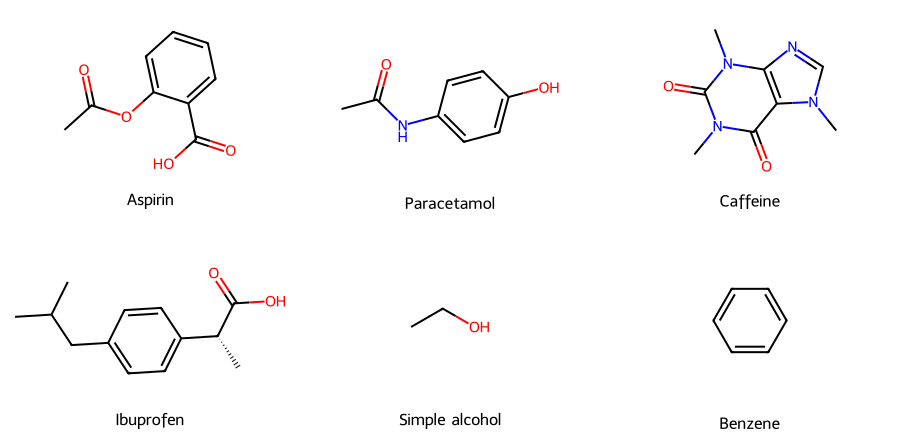

In [46]:
mols = [Chem.MolFromSmiles(item["smile"]) for item in candidate_molecules]
names = [item["name"] for item in candidate_molecules]

display(Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 220), legends=names))


## Run Prediction

This helper function:

1. Converts SMILES into MACCS features.
2. Converts features into a PyTorch tensor.
3. Sends it through the trained LSTM model.
4. Returns a predicted docking score.


In [47]:
import numpy as np

def predict_docking_score(smile):
    features = mac_keys_fingerprints(smile).astype(np.float32)

    features = torch.from_numpy(features)
    features = features.unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        prediction = model(features).double()
        prediction = prediction.squeeze().item()

    return prediction


prediction_rows = []

for item in candidate_molecules:
    predicted_score = predict_docking_score(item["smile"])

    prediction_rows.append({
        "name": item["name"],
        "smile": item["smile"],
        "predicted_docking_score": predicted_score
    })

predictions_df = pd.DataFrame(prediction_rows)
predictions_df

,name,smile,predicted_docking_score
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O,-3.799524
1,Paracetamol,CC(=O)Nc1ccc(O)cc1,-4.688617
2,Caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,-6.416243
3,Ibuprofen,CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O,-3.351804
4,Simple alcohol,CCO,-1.739184
5,Benzene,c1ccccc1,-1.593430


# 7. Rank the Molecules 🏆

Now we sort the candidates by predicted docking score.

The strongest predicted binder is the molecule with the most negative score.


In [48]:
ranked_df = predictions_df.sort_values("predicted_docking_score", ascending=True).reset_index(drop=True)
ranked_df


,name,smile,predicted_docking_score
0,Caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,-6.416243
1,Paracetamol,CC(=O)Nc1ccc(O)cc1,-4.688617
2,Aspirin,CC(=O)Oc1ccccc1C(=O)O,-3.799524
3,Ibuprofen,CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O,-3.351804
4,Simple alcohol,CCO,-1.739184
5,Benzene,c1ccccc1,-1.593430


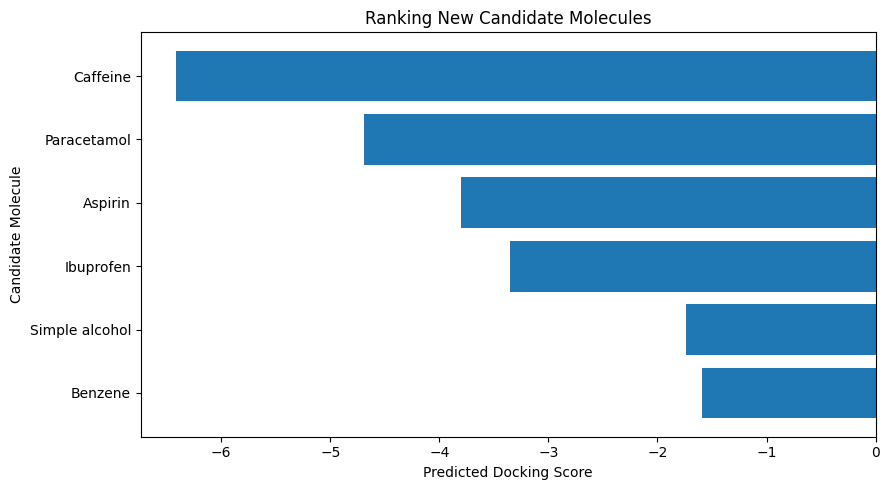

In [49]:
plt.figure(figsize=(9, 5))
plt.barh(ranked_df["name"], ranked_df["predicted_docking_score"])
plt.xlabel("Predicted Docking Score")
plt.ylabel("Candidate Molecule")
plt.title("Ranking New Candidate Molecules")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# 8. Pick the Best New Molecule ✨

The top-ranked molecule is our best candidate according to the trained model.

This does not mean it is a real drug.

It means:

> This molecule is worth prioritizing for deeper computational or experimental study.


Best candidate molecule:
Name: Caffeine
SMILES: Cn1cnc2c1c(=O)n(C)c(=O)n2C
Predicted docking score: -6.416242599487305


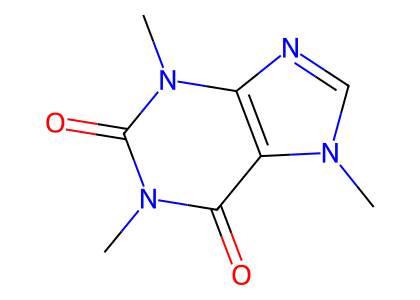

In [36]:
best_candidate = ranked_df.iloc[0]

print("Best candidate molecule:")
print("Name:", best_candidate["name"])
print("SMILES:", best_candidate["smile"])
print("Predicted docking score:", best_candidate["predicted_docking_score"])

best_mol = Chem.MolFromSmiles(best_candidate["smile"])
display(Draw.MolToImage(best_mol, size=(420, 300)))


# 9. What Did We Actually Build?

Instead of docking every molecule one-by-one:

    New molecules → Docking software → expensive

We used:

    New molecules → Molecular features → Trained LSTM model → predicted docking scores

This makes the process faster and helps us decide which molecules are worth deeper investigation.


# 10. Mini Challenge for the Audience

Try adding a new molecule below and re-run the prediction.

Example SMILES strings:

    CCO
    CCN
    CC(=O)O
    c1ccccc1
    CC(C)O

Can you create a molecule that gets a stronger predicted docking score?


In [50]:
my_new_molecule = {
    "name": "My custom molecule",
    "smile": "CCO"
}

my_score = predict_docking_score(my_new_molecule["smile"])

print("Name:", my_new_molecule["name"])
print("SMILES:", my_new_molecule["smile"])
print("Predicted docking score:", my_score)


Name: My custom molecule
SMILES: CCO
Predicted docking score: -1.7391836643218994


# Final Takeaway 🎓

The goal of Swift Dock is not to replace molecular docking.

The goal is to make the search smarter.

Machine learning can help us quickly prioritize molecules, reduce unnecessary docking calculations, and focus computational effort on the most promising candidates.

That is the main idea behind:

> **Accelerating Molecular Docking Using Machine Learning Methods**
